In [29]:
import pandas as pd

df = pd.read_csv('European_Bank (2).csv')

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


(10000, 14)

In [4]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

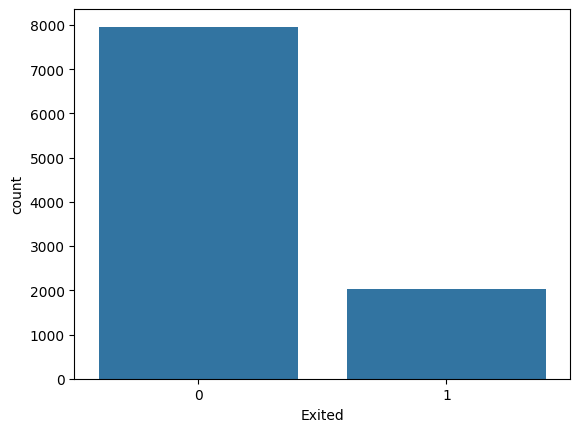

In [9]:
sns.countplot(x='Exited', data=df)
plt.show()

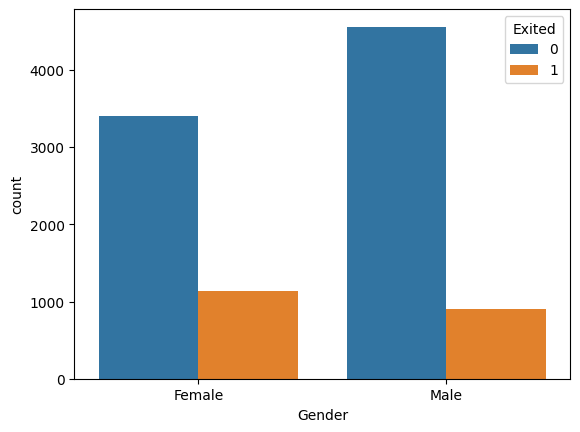

In [10]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

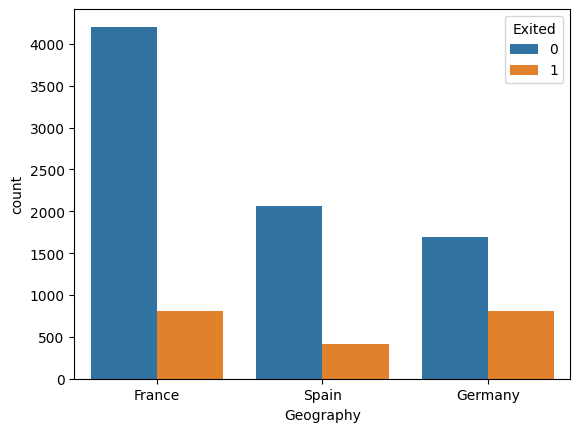

In [11]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

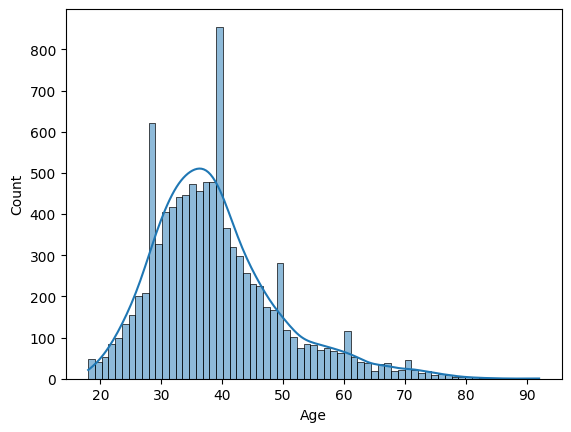

In [12]:
sns.histplot(df['Age'], kde=True)
plt.show()

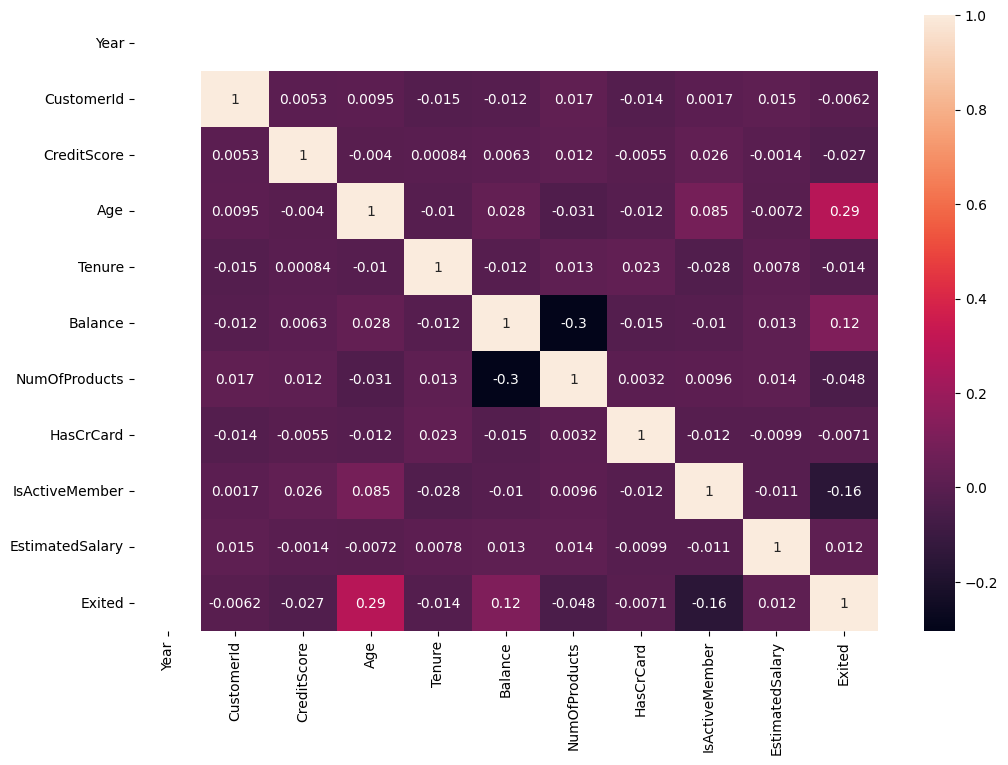

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [14]:
df.drop(['CustomerId','Surname','Year'], axis=1, inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df = pd.get_dummies(
    df,
    columns=['Geography','Gender'],
    drop_first=True
)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [16]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [18]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [21]:
y_pred = lr.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.807

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
rf_pred = rf.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, rf_pred)

0.8645

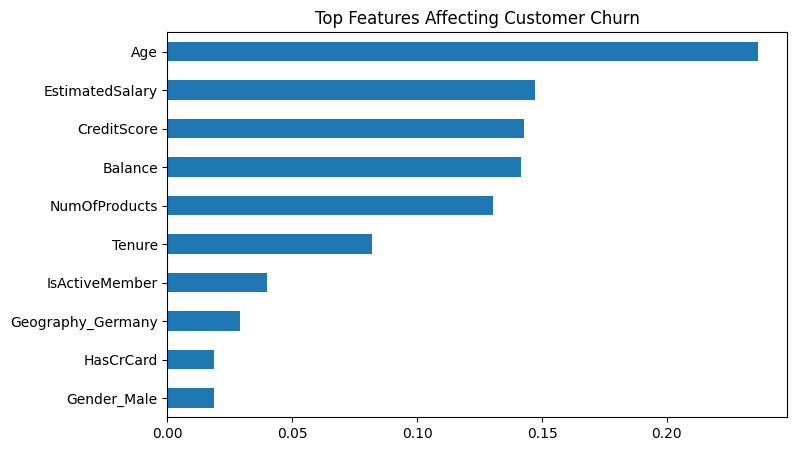

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feat_imp = pd.Series(
    importance,
    index=X.columns
)

feat_imp.sort_values().tail(10).plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Top Features Affecting Customer Churn")
plt.show()

In [27]:
rf.predict_proba(X_test[:5])

array([[0.92, 0.08],
       [0.98, 0.02],
       [0.96, 0.04],
       [0.98, 0.02],
       [0.91, 0.09]])

In [28]:
import pickle

pickle.dump(rf, open('churn_model.pkl', 'wb'))

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [31]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [32]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


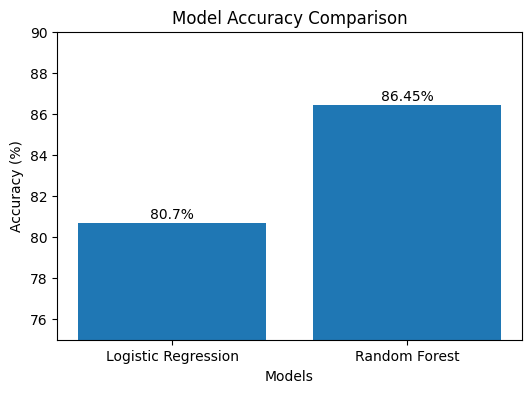

In [34]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']
accuracy = [80.70, 86.45]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')
plt.title('Model Accuracy Comparison')
plt.ylim(75,90)

for i, v in enumerate(accuracy):
    plt.text(i, v+0.2, str(v)+'%', ha='center')

plt.show()

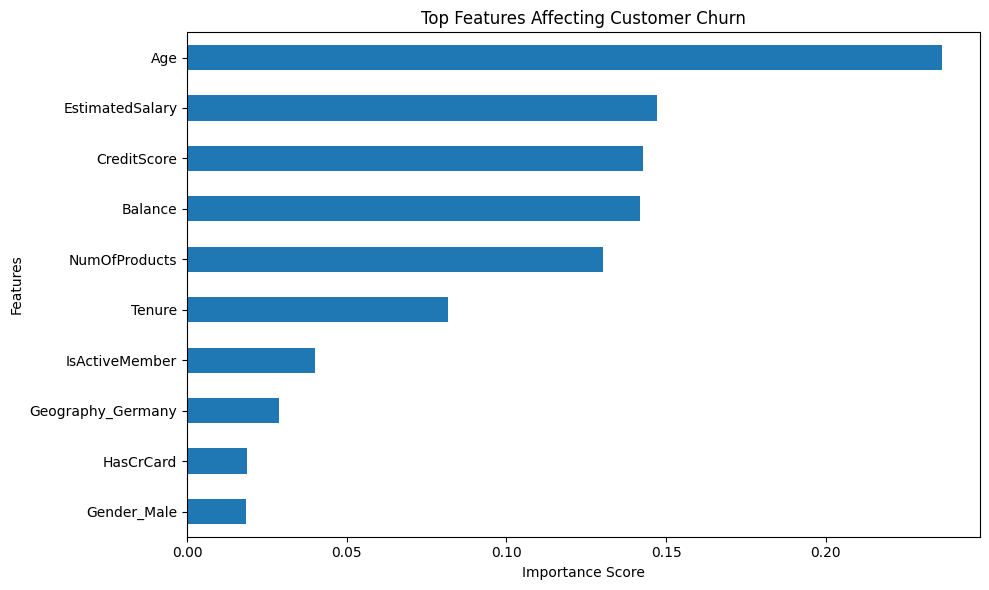

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance values
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

# Top 10 features
top_features = feature_importance.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh')

plt.title('Top Features Affecting Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()